In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import mlflow
import mlflow.lightgbm

hammadde piyasa verilerini ekleyelim (epias dogalgaz ağırlıklı ortalama)

In [15]:
spg_1 = pd.read_excel("../data/raw/SGP_Fiyatlar-01012024-01012025.xlsx")
spg_2 = pd.read_excel("../data/raw/SGP_Fiyatlar-01012025-25122025.xlsx")

c:\Users\90546\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\90546\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [16]:
spg_data = pd.concat([spg_1, spg_2], ignore_index=True)

In [17]:
spg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726 entries, 0 to 725
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Gaz Günü          726 non-null    datetime64[ns]
 1   GÖF(TL/1000 sm3)  726 non-null    float64       
 2   GİF(TL/1000 sm3)  245 non-null    float64       
 3   GEF(TL/1000 sm3)  645 non-null    float64       
 4   AOF(TL/1000 sm3)  725 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 28.5 KB


In [18]:
spg_data = spg_data[["Gaz Günü","AOF(TL/1000 sm3)"]]

In [19]:
spg_data.head()

,Gaz Günü,AOF(TL/1000 sm3)
0,2024-01-01,12246.85
1,2024-01-02,12100.00
2,2024-01-03,11982.51
3,2024-01-04,11861.97
4,2024-01-05,11607.73


In [20]:
spg_data["yesterday_spg"] = spg_data["AOF(TL/1000 sm3)"].shift(1)

In [21]:
spg_data.head()

,Gaz Günü,AOF(TL/1000 sm3),yesterday_spg
0,2024-01-01,12246.85,NaN
1,2024-01-02,12100.00,12246.85
2,2024-01-03,11982.51,12100.00
3,2024-01-04,11861.97,11982.51
4,2024-01-05,11607.73,11861.97


In [23]:
veri = pd.read_pickle('../data/processed/05_model-2.pkl')

In [27]:
spg_data['Tarih'] = pd.to_datetime(spg_data['Gaz Günü']) # Sütun adın 'Tarih' ise
spg_data = spg_data.set_index('Tarih')


veri['Gun'] = veri.index.normalize() # 2024-01-01 14:00 -> 2024-01-01 yapar

spg_data = spg_data[~spg_data.index.duplicated(keep='first')]
veri['Dogalgaz_Fiyati'] = veri['Gun'].map(spg_data['yesterday_spg'])

# Eksik verileri (Tatil vs.) doldur
veri['Dogalgaz_Fiyati'] = veri['Dogalgaz_Fiyati'].ffill().bfill()

# Gereksiz 'Gun' sütununu atabilirsin
veri = veri.drop(columns=['Gun'])

print(veri[['Dogalgaz_Fiyati']].head())

                     Dogalgaz_Fiyati
2024-01-18 23:00:00         11337.34
2024-01-19 00:00:00         11534.59
2024-01-19 01:00:00         11534.59
2024-01-19 02:00:00         11534.59
2024-01-19 03:00:00         11534.59


In [28]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16861 entries, 2024-01-18 23:00:00 to 2025-12-20 11:00:00
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   PTF               16861 non-null  float64 
 1   month             16861 non-null  category
 2   day               16861 non-null  category
 3   season            16861 non-null  category
 4   Rolling_Mean_168  16861 non-null  float64 
 5   Is_Holiday        16861 non-null  category
 6   Is_Weekend        16861 non-null  category
 7   Lag_24            16861 non-null  float64 
 8   Lag_168           16861 non-null  float64 
 9   Lag_48            16861 non-null  float64 
 10  Lag_72            16861 non-null  float64 
 11  Lag_96            16861 non-null  float64 
 12  Hour              16861 non-null  int32   
 13  DayOfWeek         16861 non-null  int32   
 14  Yuk_Tahmin_Plani  16861 non-null  int64   
 15  yesil_enerji      16861 non-null  f

dogalgaz fiyatı ile target arasındaki ilişkiyi inceleyelim.

Korelasyon Tablosu:
                      PTF
PTF              1.000000
Gaz_Oran         0.673762
USD_TRY          0.320550
Dogalgaz_Fiyati  0.314594
----------------------------------------


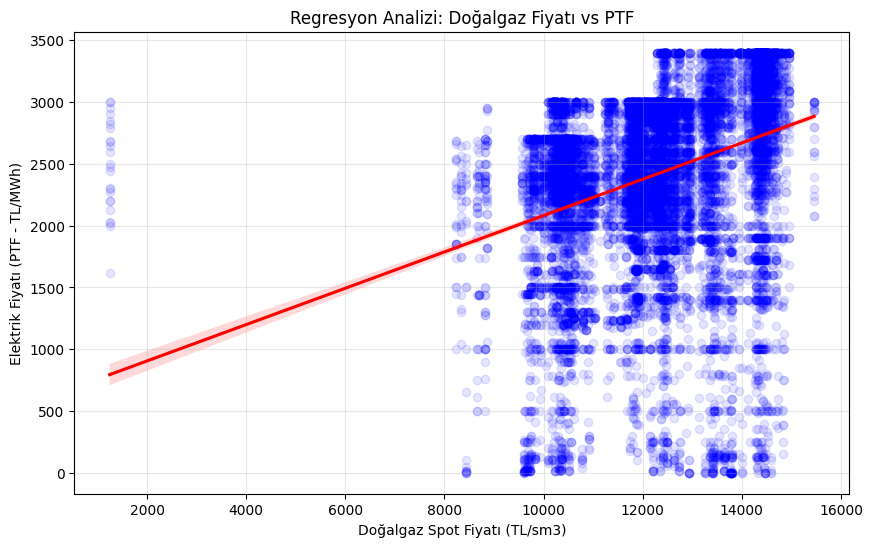

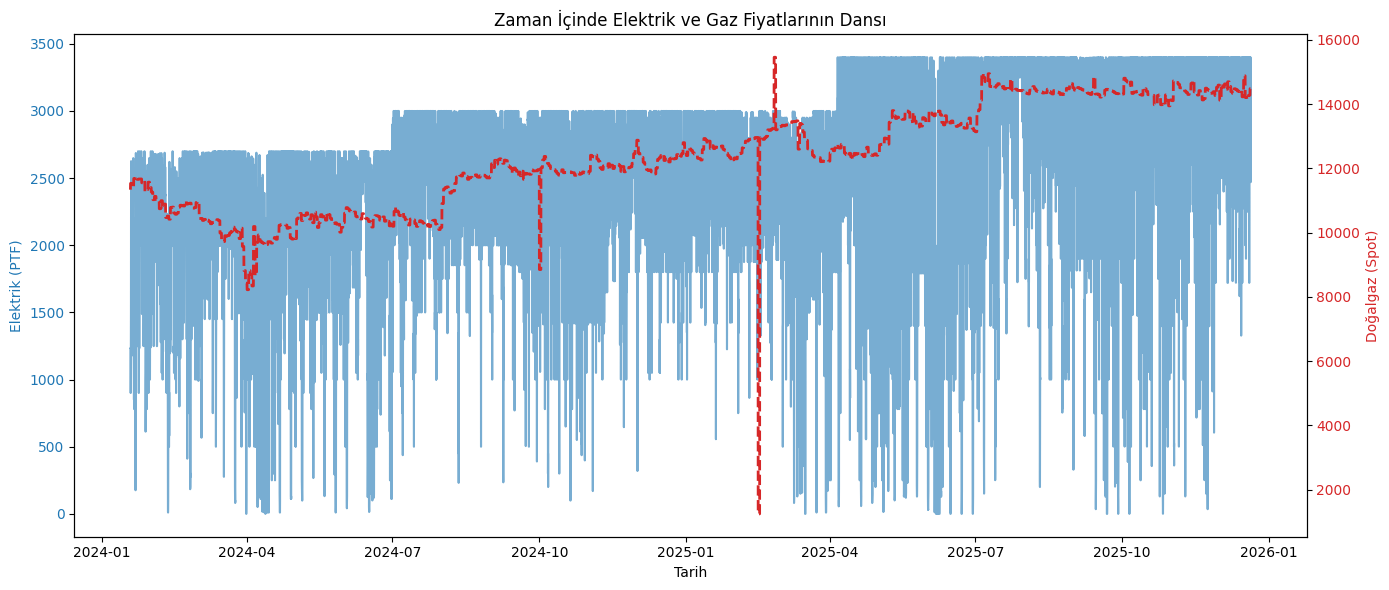

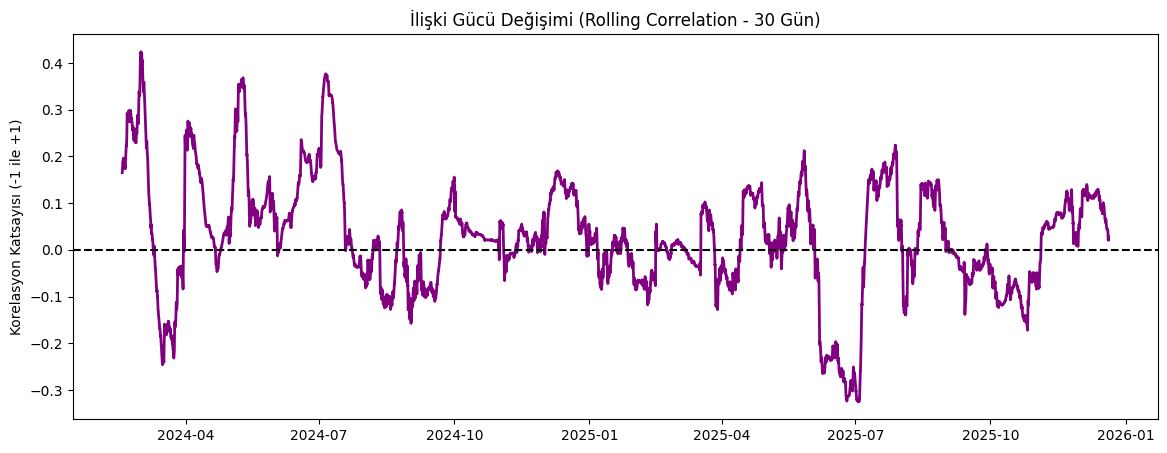

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Veri setinin kopyasını alalım (Bozulmasın)
# df = veri.copy()  # Senin dataframe adın 'veri' ise bunu aç


# 1. KORELASYON MATRİSİ (SAYISAL KANIT)
# Sadece ilgili sütunları seçip korelasyonlarına bakalım (-1 ile +1 arası)
corr_cols = ['PTF', 'Dogalgaz_Fiyati', 'Gaz_Oran', 'USD_TRY']
corr_matrix = veri[corr_cols].corr()

print("Korelasyon Tablosu:")
print(corr_matrix[['PTF']].sort_values(by='PTF', ascending=False))
print("-" * 40)

# 2. GRAFİK: SCATTER PLOT (DAĞILIM)
# Gaz fiyatı arttıkça PTF ne yapmış?
plt.figure(figsize=(10, 6))
sns.regplot(x='Dogalgaz_Fiyati', y='PTF', data=veri, 
            scatter_kws={'alpha':0.1, 'color':'blue'}, line_kws={'color':'red'})
plt.title('Regresyon Analizi: Doğalgaz Fiyatı vs PTF')
plt.xlabel('Doğalgaz Spot Fiyatı (TL/sm3)')
plt.ylabel('Elektrik Fiyatı (PTF - TL/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

# 3. GRAFİK: ZAMAN ÇİZELGESİ (BİRLİKTE HAREKET)
# İki veriyi farklı eksenlerde (Twin Axis) çizelim ki hareketleri kıyaslayalım.
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Tarih')
ax1.set_ylabel('Elektrik (PTF)', color=color)
ax1.plot(veri.index, veri['PTF'], color=color, alpha=0.6, label='PTF')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # İkinci Y ekseni
color = 'tab:red'
ax2.set_ylabel('Doğalgaz (Spot)', color=color)
ax2.plot(veri.index, veri['Dogalgaz_Fiyati'], color=color, linestyle='--', linewidth=2, label='Gaz Fiyatı')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Zaman İçinde Elektrik ve Gaz Fiyatlarının Dansı')
fig.tight_layout()
plt.show()

# 4. GRAFİK: ROLLING CORRELATION (İLİŞKİNİN GÜCÜ DEĞİŞİYOR MU?)
# Son 30 günün (30*24 saat) korelasyonuna bakalım. 
# İlişki bazen kopabilir (Yazın güneş çokken gazın etkisi azalır).
rolling_corr = veri['PTF'].rolling(window=30*24).corr(veri['Dogalgaz_Fiyati'])

plt.figure(figsize=(14, 5))
plt.plot(rolling_corr, color='purple', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('İlişki Gücü Değişimi (Rolling Correlation - 30 Gün)')
plt.ylabel('Korelasyon Katsayısı (-1 ile +1)')
plt.show()

Eski (Saf Gaz Fiyatı) Korelasyonu : 0.3146
Yeni (Maliyet Baskısı) Korelasyonu : 0.6876


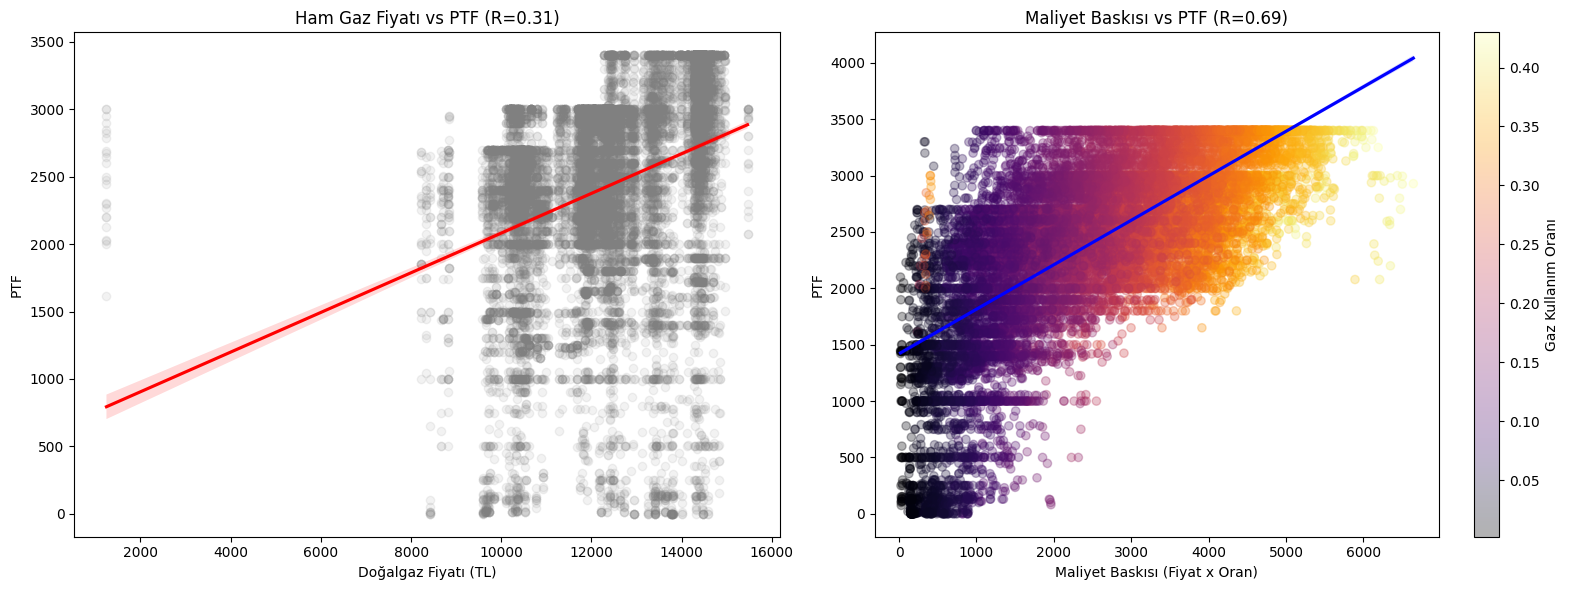

In [34]:
veri['Maliyet_Baskisi'] = veri['Dogalgaz_Fiyati'] * veri['Gaz_Oran']

corr_raw = veri['Dogalgaz_Fiyati'].corr(veri['PTF'])
corr_smart = veri['Maliyet_Baskisi'].corr(veri['PTF'])

print("="*40)
print(f"Eski (Saf Gaz Fiyatı) Korelasyonu : {corr_raw:.4f}")
print(f"Yeni (Maliyet Baskısı) Korelasyonu : {corr_smart:.4f}")
print("="*40)

# --- 3. GÖRSEL KANIT ---
# İki durumu yan yana çizelim
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Eski Durum (Zayıf)
sns.regplot(x='Dogalgaz_Fiyati', y='PTF', data=veri, ax=axes[0], 
            scatter_kws={'alpha':0.1, 'color':'gray'}, line_kws={'color':'red'})
axes[0].set_title(f'Ham Gaz Fiyatı vs PTF (R={corr_raw:.2f})')
axes[0].set_xlabel('Doğalgaz Fiyatı (TL)')

# Grafik 2: Yeni Durum (Güçlü)
# Renklendirmeyi "Gaz_Oran"a göre yapalım ki yoğunluğu görelim
sc = axes[1].scatter(veri['Maliyet_Baskisi'], veri['PTF'], 
                     c=veri['Gaz_Oran'], cmap='inferno', alpha=0.3)
sns.regplot(x='Maliyet_Baskisi', y='PTF', data=veri, ax=axes[1], scatter=False, line_kws={'color':'blue'})
axes[1].set_title(f'Maliyet Baskısı vs PTF (R={corr_smart:.2f})')
axes[1].set_xlabel('Maliyet Baskısı (Fiyat x Oran)')

# Renk çubuğu ekle
plt.colorbar(sc, ax=axes[1], label='Gaz Kullanım Oranı')
plt.tight_layout()
plt.show()

🎨 GRAFİK ANALİZİ HAZIRLANIYOR...


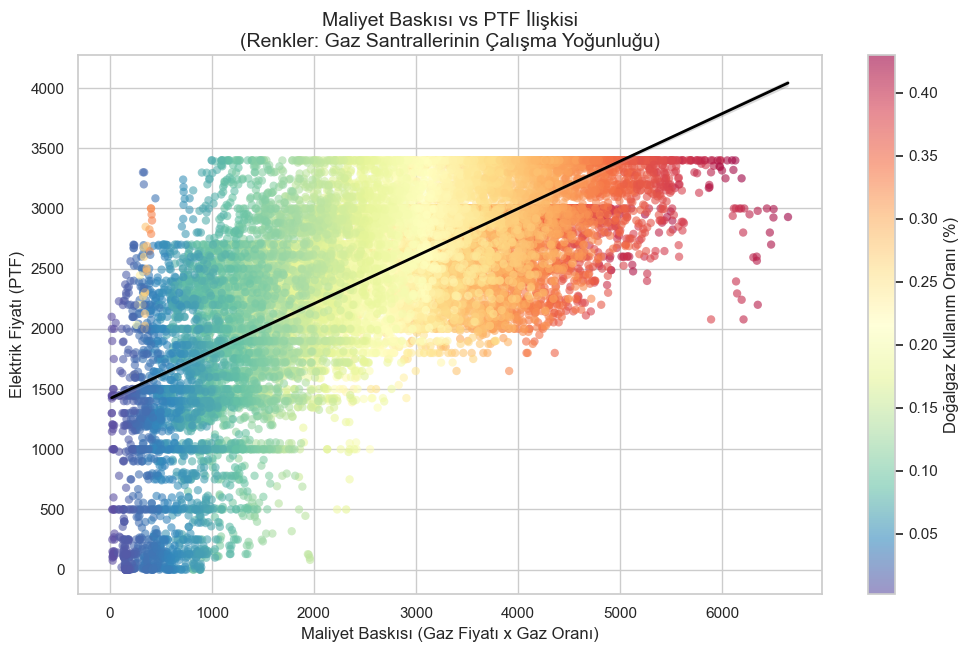


 yorum 1: Noktalar sağ yukarı doğru dar bir koridorda mı gidiyor? Öyleyse ilişki mükemmeldir.


C:\Users\90546\AppData\Local\Temp\ipykernel_31576\3686812941.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Baski_Seviyesi', y='PTF', data=df_analiz, palette='Reds')


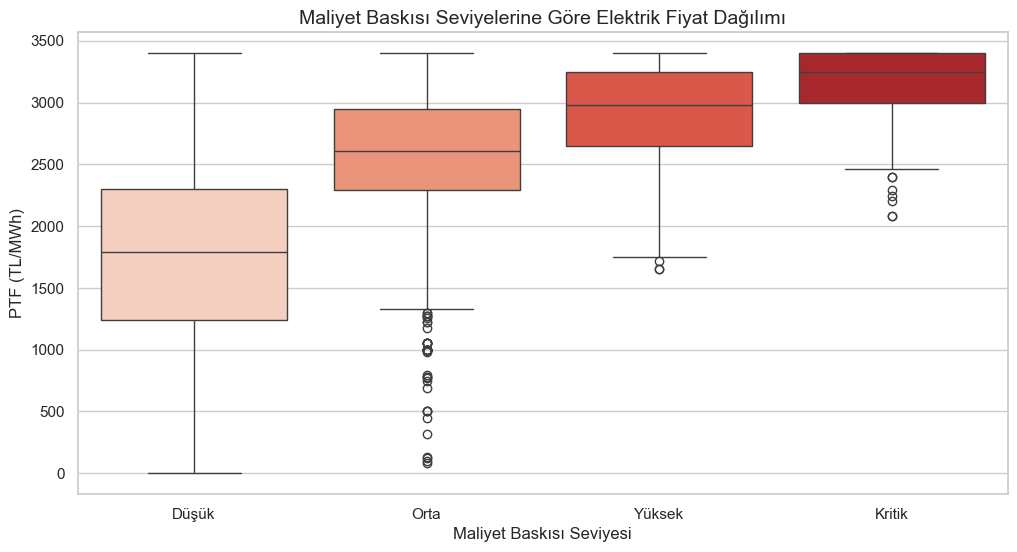


 Yorum 2: Kutular birbirinden merdiven gibi yukarıda mı? Yani 'Yüksek' baskıda fiyatlar kesinlikle daha mı pahalı?


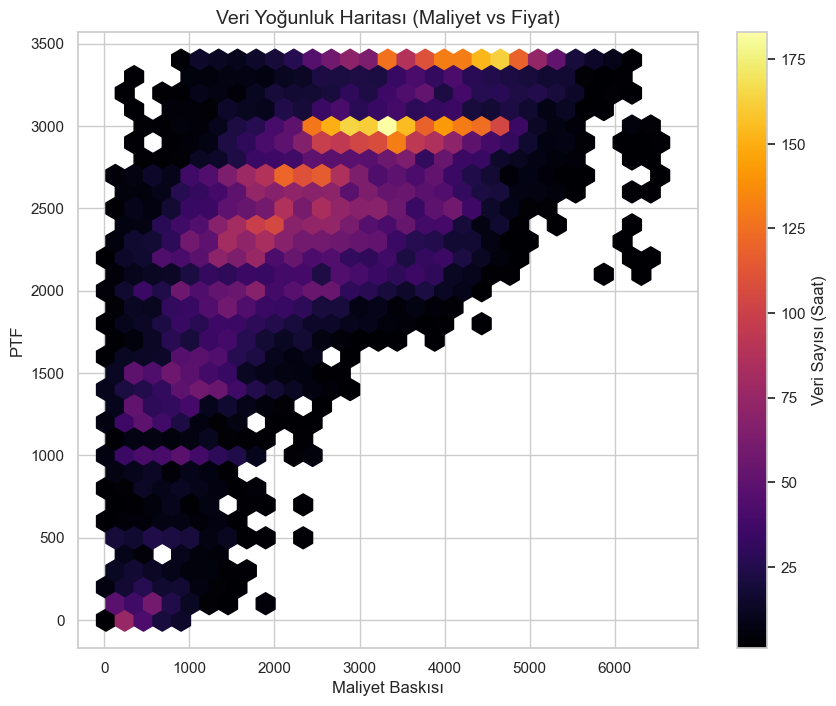

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Veri setinin kopyasını alalım
df_analiz = veri.copy().dropna()

# Görsellik ayarları
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)


# --- GRAFİK 1: RENKLİ SCATTER PLOT (EN ÖNEMLİSİ) ---
# X ekseni: Maliyet Baskısı, Y ekseni: PTF
# Renkler: Gaz Kullanım Oranı (Kırmızılar yüksek kullanım)
plt.figure(figsize=(12, 7))
sc = plt.scatter(df_analiz['Maliyet_Baskisi'], df_analiz['PTF'], 
                 c=df_analiz['Gaz_Oran'], cmap='Spectral_r', alpha=0.6, edgecolors='none')
plt.colorbar(sc, label='Doğalgaz Kullanım Oranı (%)')

# Trend Çizgisi (Regresyon)
sns.regplot(x='Maliyet_Baskisi', y='PTF', data=df_analiz, scatter=False, color='black', line_kws={'linewidth': 2})

plt.title('Maliyet Baskısı vs PTF İlişkisi\n(Renkler: Gaz Santrallerinin Çalışma Yoğunluğu)', fontsize=14)
plt.xlabel('Maliyet Baskısı (Gaz Fiyatı x Gaz Oranı)', fontsize=12)
plt.ylabel('Elektrik Fiyatı (PTF)', fontsize=12)
plt.show()

print("\n yorum 1: Noktalar sağ yukarı doğru dar bir koridorda mı gidiyor? Öyleyse ilişki mükemmeldir.")


# --- GRAFİK 2: KUTU GRAFİĞİ (BOXPLOT) - AYRIŞTIRMA GÜCÜ ---
# Maliyet Baskısını 4 seviyeye bölelim: Düşük, Orta, Yüksek, Kritik
df_analiz['Baski_Seviyesi'] = pd.cut(df_analiz['Maliyet_Baskisi'], bins=4, labels=['Düşük', 'Orta', 'Yüksek', 'Kritik'])

plt.figure(figsize=(12, 6))
sns.boxplot(x='Baski_Seviyesi', y='PTF', data=df_analiz, palette='Reds')
plt.title('Maliyet Baskısı Seviyelerine Göre Elektrik Fiyat Dağılımı', fontsize=14)
plt.xlabel('Maliyet Baskısı Seviyesi', fontsize=12)
plt.ylabel('PTF (TL/MWh)', fontsize=12)
plt.show()

print("\n Yorum 2: Kutular birbirinden merdiven gibi yukarıda mı? Yani 'Yüksek' baskıda fiyatlar kesinlikle daha mı pahalı?")


# --- GRAFİK 3: YOĞUNLUK HARİTASI (HEXBIN) ---
# Verinin nerede yoğunlaştığını gösterir
plt.figure(figsize=(10, 8))
plt.hexbin(df_analiz['Maliyet_Baskisi'], df_analiz['PTF'], gridsize=30, cmap='inferno', mincnt=1)
plt.colorbar(label='Veri Sayısı (Saat)')
plt.title('Veri Yoğunluk Haritası (Maliyet vs Fiyat)', fontsize=14)
plt.xlabel('Maliyet Baskısı', fontsize=12)
plt.ylabel('PTF', fontsize=12)
plt.show()

modele gidelim

🔥 MODEL EĞİTİMİ BAŞLIYOR... (Feature: Maliyet Baskısı Devrede)
📊 Eğitim Seti: 14929 satır | Test Seti: 1932 satır
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[941]	Egitim's l1: 117.726	Test's l1: 215.881

🏆 FİNAL SONUÇLAR:
🎯 R2 Skoru (Başarı) : 0.7932
📉 MAE (Hata)        : 215.88 TL
📊 WMAPE (Hata %)    : %7.68


C:\Users\90546\AppData\Local\Temp\ipykernel_31576\1257250520.py:78: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_week = results_df.last('7D') # Son 7 gün


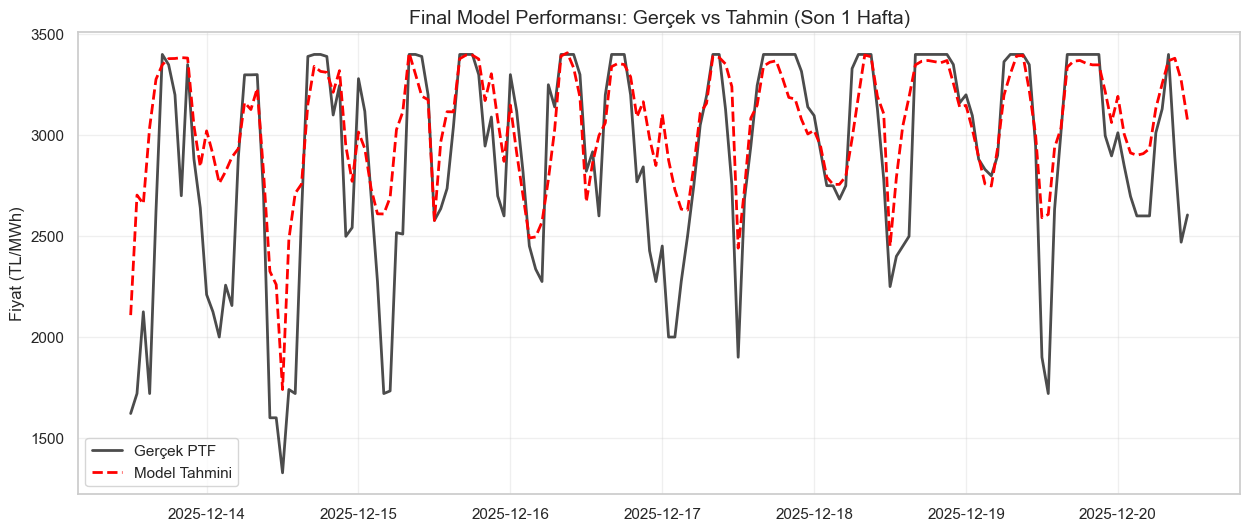

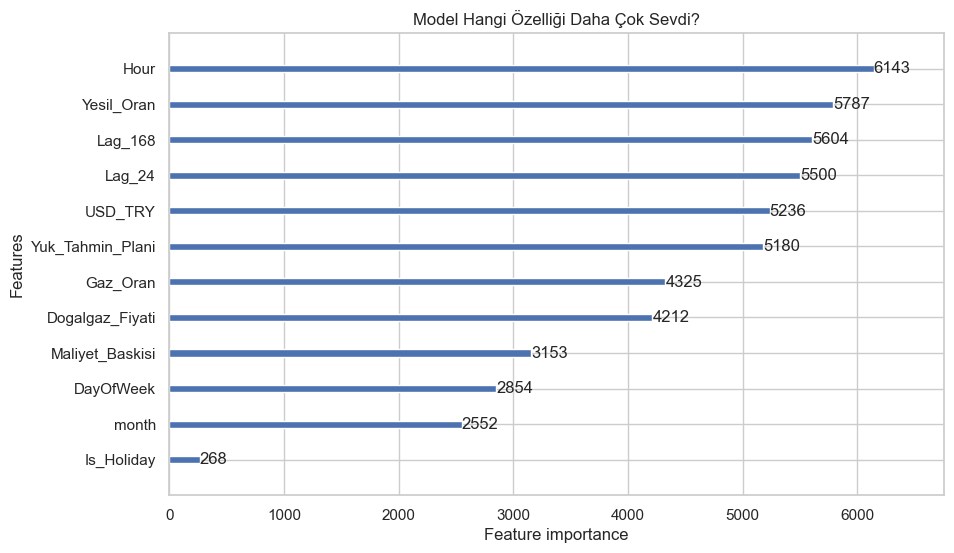

In [36]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

print("🔥 MODEL EĞİTİMİ BAŞLIYOR... (Feature: Maliyet Baskısı Devrede)")

# 1. ÖZELLİK SEÇİMİ (ŞAMPİYONLAR LİGİ KADROSU)
features = [
    # Zaman Sinyalleri
    'Hour', 'DayOfWeek', 'month', 'Is_Holiday',
    
    # Piyasa Durumu
    'Yuk_Tahmin_Plani', 'Yesil_Oran', 'Gaz_Oran', 'USD_TRY',
    
    # Hafıza (Geçmiş)
    'Lag_24', 'Lag_168',
    
    # 🔥 YENİ GÜÇ KAYNAKLARI
    'Dogalgaz_Fiyati',  # Ham Fiyat (Dünden gelen)
    'Maliyet_Baskisi'   # Fiyat x Oran (Ana belirleyici)
]

target = 'PTF'

# Veriyi temizleyelim (NaN varsa uçuralım)
model_df = veri.copy().dropna()

# 2. TRAIN / TEST AYRIMI (Zaman Bazlı)
# Son 2 ayı test için ayıralım, gerisiyle eğitelim.
split_date = '2025-10-01' 

X_train = model_df[model_df.index < split_date][features]
y_train = model_df[model_df.index < split_date][target]
X_test = model_df[model_df.index >= split_date][features]
y_test = model_df[model_df.index >= split_date][target]

print(f"📊 Eğitim Seti: {len(X_train)} satır | Test Seti: {len(X_test)} satır")

# 3. MODELİ KURMA VE EĞİTME
model = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=5000,      # Uzun soluklu öğrenme
    learning_rate=0.015,    # Yavaş ve sindirerek (Hassas ayar)
    num_leaves=55,          # Ağaç karmaşıklığı
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['Egitim', 'Test'],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=True)] # Sabır süresini biraz artırdık
)

# 4. TAHMİN VE SKORLAMA
preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
wmape = (np.sum(np.abs(y_test - preds)) / np.sum(y_test)) * 100

print("\n" + "="*50)
print(f"🏆 FİNAL SONUÇLAR:")
print(f"🎯 R2 Skoru (Başarı) : {r2:.4f}")
print(f"📉 MAE (Hata)        : {mae:.2f} TL")
print(f"📊 WMAPE (Hata %)    : %{wmape:.2f}")
print("="*50)

# --- GÖRSELLEŞTİRME 1: TAHMİN vs GERÇEK (SON 1 HAFTA) ---
# Bütün grafiği çizersek karışır, sadece son 1 haftaya zoom yapalım.
results_df = pd.DataFrame({'Gerçek': y_test, 'Tahmin': preds}, index=X_test.index)
last_week = results_df.last('7D') # Son 7 gün

plt.figure(figsize=(15, 6))
plt.plot(last_week.index, last_week['Gerçek'], label='Gerçek PTF', color='black', linewidth=2, alpha=0.7)
plt.plot(last_week.index, last_week['Tahmin'], label='Model Tahmini', color='red', linestyle='--', linewidth=2)
plt.title('Final Model Performansı: Gerçek vs Tahmin (Son 1 Hafta)', fontsize=14)
plt.ylabel('Fiyat (TL/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- GÖRSELLEŞTİRME 2: FEATURE IMPORTANCE (KRAL KİM?) ---
lgb.plot_importance(model, max_num_features=15, title='Model Hangi Özelliği Daha Çok Sevdi?', figsize=(10, 6))
plt.show()

korelasyonu daha yüksek olan maliyet baskısı nasıl oldu da dogalgaz maliyetin altında kaldı?
Multicollinearity : aynı seyi anlatan bir çok bilgi vermis olabiliriz.
mesela; maliyet baskısı zaten gaz oranı ve dogalgaz fiyatı bilgisini taşıyor. ve dogalgaz fiyatı  korelasyonu oldukca düşük
o zaman dogalgaz fiyatını kaldıralım, dolar fiyatını kaldıralım ve modele tekrar bi bakalım



YENİ SONUÇLAR (Ham Fiyat Çıkarıldı):
R2 Skoru : 0.7789 (Eski: 0.7932)
MAE      : 225.18 (Eski: 215.88)
WMAPE    : %8.01


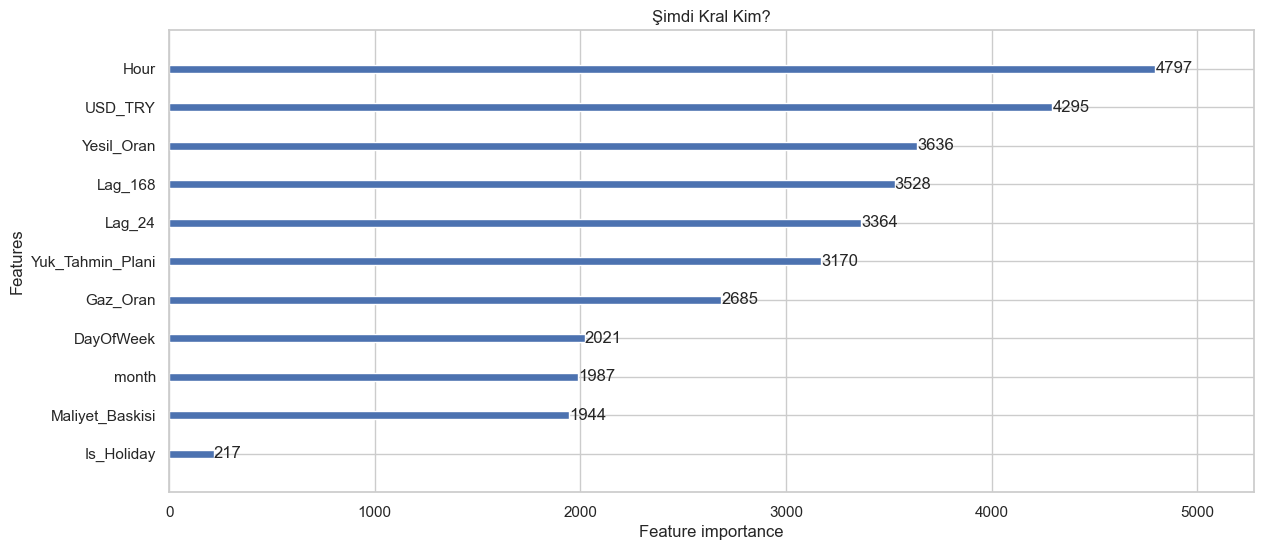

In [38]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error


# YENİ ÖZELLİK LİSTESİ (Dikkat: 'Dogalgaz_Fiyati' YOK!)
features_v2 = [
    'Hour', 'DayOfWeek', 'month', 'Is_Holiday',
    'Yuk_Tahmin_Plani',
    'Yesil_Oran', 
    'Gaz_Oran',       # Bunu tutuyoruz, sistemin çalışma şeklini anlatıyor
    'USD_TRY',
    'Lag_24', 'Lag_168',
    
    # TEK FİYAT KAYNAĞI ARTIK BU:
    'Maliyet_Baskisi' 
]

# Eğitim (Aynı parametrelerle)
model_v2 = lgb.LGBMRegressor(
    objective='regression', metric='mae', n_estimators=5000,
    learning_rate=0.015, num_leaves=55, random_state=42, n_jobs=-1, verbosity=-1
)

# Tekrar Eğit
model_v2.fit(
    X_train[features_v2], y_train,
    eval_set=[(X_test[features_v2], y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)

# Sonuçlar
preds_v2 = model_v2.predict(X_test[features_v2])
r2_v2 = r2_score(y_test, preds_v2)
mae_v2 = mean_absolute_error(y_test, preds_v2)
wmape_v2 = (sum(abs(y_test - preds_v2)) / sum(y_test)) * 100

print("\n" + "="*40)
print(f"YENİ SONUÇLAR (Ham Fiyat Çıkarıldı):")
print(f"R2 Skoru : {r2_v2:.4f} (Eski: {r2:.4f})")
print(f"MAE      : {mae_v2:.2f} (Eski: {mae:.2f})")
print(f"WMAPE    : %{wmape_v2:.2f}")
print("="*40)

# Feature Importance
lgb.plot_importance(model_v2, max_num_features=15, title='Şimdi Kral Kim?')
plt.show()

dolarsız deneyelim


YENİ SONUÇLAR (Dolar Çıkarıldı):
R2 Skoru : 0.8109 (Eski: 0.7932)
MAE      : 227.44 (Eski: 215.88)
WMAPE    : %8.10


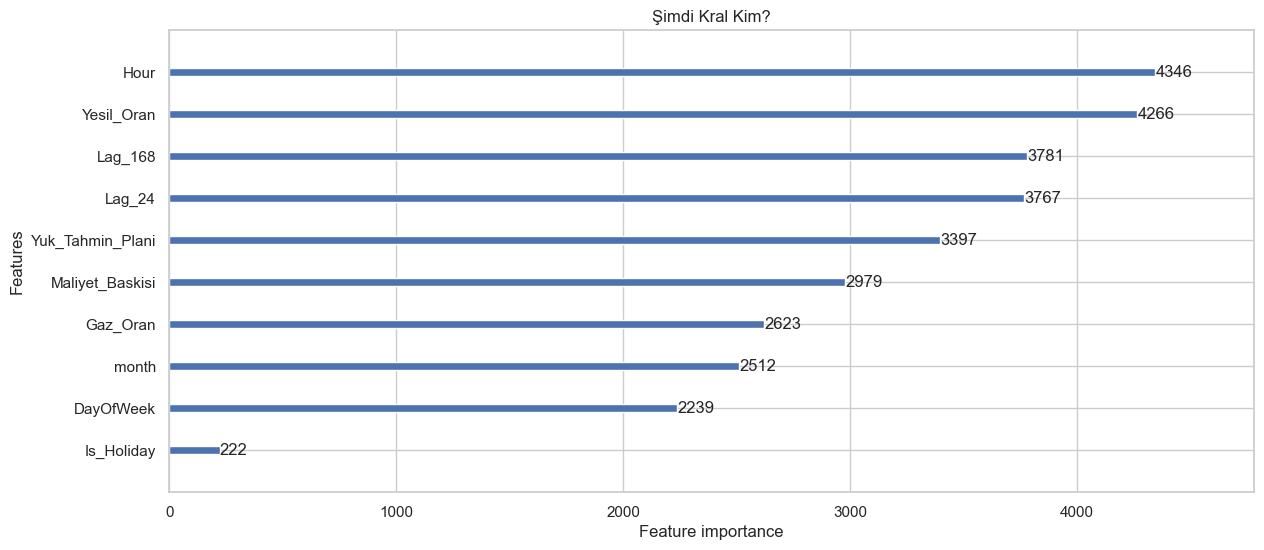

In [40]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error


# YENİ ÖZELLİK LİSTESİ (Dikkat: 'Dogalgaz_Fiyati' YOK!)
features_v2 = [
    'Hour', 'DayOfWeek', 'month', 'Is_Holiday',
    'Yuk_Tahmin_Plani',
    'Yesil_Oran', 
    'Gaz_Oran',       # Bunu tutuyoruz, sistemin çalışma şeklini anlatıyor
    'Lag_24', 'Lag_168',
    
    # TEK FİYAT KAYNAĞI ARTIK BU:
    'Maliyet_Baskisi' 
]

# Eğitim (Aynı parametrelerle)
model_v2 = lgb.LGBMRegressor(
    objective='regression', metric='mae', n_estimators=5000,
    learning_rate=0.015, num_leaves=55, random_state=42, n_jobs=-1, verbosity=-1
)

# Tekrar Eğit
model_v2.fit(
    X_train[features_v2], y_train,
    eval_set=[(X_test[features_v2], y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)

# Sonuçlar
preds_v2 = model_v2.predict(X_test[features_v2])
r2_v2 = r2_score(y_test, preds_v2)
mae_v2 = mean_absolute_error(y_test, preds_v2)
wmape_v2 = (sum(abs(y_test - preds_v2)) / sum(y_test)) * 100

print("\n" + "="*40)
print(f"YENİ SONUÇLAR (Dolar Çıkarıldı):")
print(f"R2 Skoru : {r2_v2:.4f} (Eski: {r2:.4f})")
print(f"MAE      : {mae_v2:.2f} (Eski: {mae:.2f})")
print(f"WMAPE    : %{wmape_v2:.2f}")
print("="*40)

# Feature Importance
lgb.plot_importance(model_v2, max_num_features=15, title='Şimdi Kral Kim?')
plt.show()

dolarsız ve hammade fiyatsız hiperparametre optimizasyonu yapalım

In [41]:
import optuna
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

# Gereksiz uyarıları kapatalım
warnings.filterwarnings('ignore')

print("🚀 HİPERPARAMETRE AVI BAŞLIYOR... (Hedef: En Düşük MAE)")

# 1. ÖZELLİK SETİNİ KİLİTLE (Dolarsız ve Saf Fiyatsız)
features_opt = [
    'Hour', 'DayOfWeek', 'month', 'Is_Holiday',
    'Yuk_Tahmin_Plani',
    'Yesil_Oran', 
    'Gaz_Oran',       
    'Lag_24', 'Lag_168',
    'Maliyet_Baskisi' # Tek Fiyat Sinyali
]

# Eğitim verilerini hazırlayalım (Önceki split ile aynı)
split_date = '2025-10-01'
X_train_opt = veri[veri.index < split_date][features_opt]
y_train_opt = veri[veri.index < split_date]['PTF']
X_test_opt = veri[veri.index >= split_date][features_opt]
y_test_opt = veri[veri.index >= split_date]['PTF']

# 2. OPTUNA OBJECTIVE FONKSİYONU
def objective(trial):
    # Denenecek Parametre Aralıkları
    param = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'n_jobs': -1,
        'random_state': 42,
        'n_estimators': 5000,  # Sabit yüksek sayı (Early stopping ile duracak)
        
        # 🧪 Optimize Edilecek Değişkenler:
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05), # Hız
        'num_leaves': trial.suggest_int('num_leaves', 30, 100),             # Karmaşıklık
        'max_depth': trial.suggest_int('max_depth', 7, 15),                 # Derinlik
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),# Aşırı öğrenme önleyici
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),            # Satır örnekleme
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0), # Sütun örnekleme
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),            # L1 Regülarizasyon (Gürültü silici)
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),          # L2 Regülarizasyon
    }

    # Modeli Kur
    model = lgb.LGBMRegressor(**param)
    
    # Eğit
    model.fit(
        X_train_opt, y_train_opt,
        eval_set=[(X_test_opt, y_test_opt)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    # Tahmin Yap ve MAE Döndür
    preds = model.predict(X_test_opt)
    mae = mean_absolute_error(y_test_opt, preds)
    return mae

# 3. ÇALIŞTIR (20 Deneme Yapacak)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("\n" + "="*40)
print("🏆 EN İYİ PARAMETRELER BULUNDU!")
print("="*40)
print(f"🥇 En Düşük MAE: {study.best_value:.2f} TL")
print("🧩 Parametreler:", study.best_params)

c:\Users\90546\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-25 16:59:20,836] A new study created in memory with name: no-name-8321e4c9-a31d-486a-8f07-c44f2561df42


🚀 HİPERPARAMETRE AVI BAŞLIYOR... (Hedef: En Düşük MAE)


[I 2025-12-25 16:59:30,805] Trial 0 finished with value: 226.31109689405133 and parameters: {'learning_rate': 0.006937129535393682, 'num_leaves': 71, 'max_depth': 12, 'min_child_samples': 17, 'subsample': 0.9455078844236526, 'colsample_bytree': 0.936784252032667, 'reg_alpha': 0.14073475925127854, 'reg_lambda': 0.15508285992779325}. Best is trial 0 with value: 226.31109689405133.
[I 2025-12-25 16:59:32,617] Trial 1 finished with value: 234.09782441115314 and parameters: {'learning_rate': 0.03076653314776411, 'num_leaves': 84, 'max_depth': 12, 'min_child_samples': 18, 'subsample': 0.6512670796090534, 'colsample_bytree': 0.7260197882736381, 'reg_alpha': 0.8821768719150263, 'reg_lambda': 0.06683045849002811}. Best is trial 0 with value: 226.31109689405133.
[I 2025-12-25 16:59:34,631] Trial 2 finished with value: 228.96451771264162 and parameters: {'learning_rate': 0.04444275522857023, 'num_leaves': 94, 'max_depth': 14, 'min_child_samples': 46, 'subsample': 0.869162125273829, 'colsample_byt


🏆 EN İYİ PARAMETRELER BULUNDU!
🥇 En Düşük MAE: 225.49 TL
🧩 Parametreler: {'learning_rate': 0.04005304861684045, 'num_leaves': 98, 'max_depth': 11, 'min_child_samples': 25, 'subsample': 0.8960790850099875, 'colsample_bytree': 0.8948813773457979, 'reg_alpha': 0.008706604800905855, 'reg_lambda': 0.033416062988701034}



R2 Skoru : 0.8111
MAE      : 228.98 TL


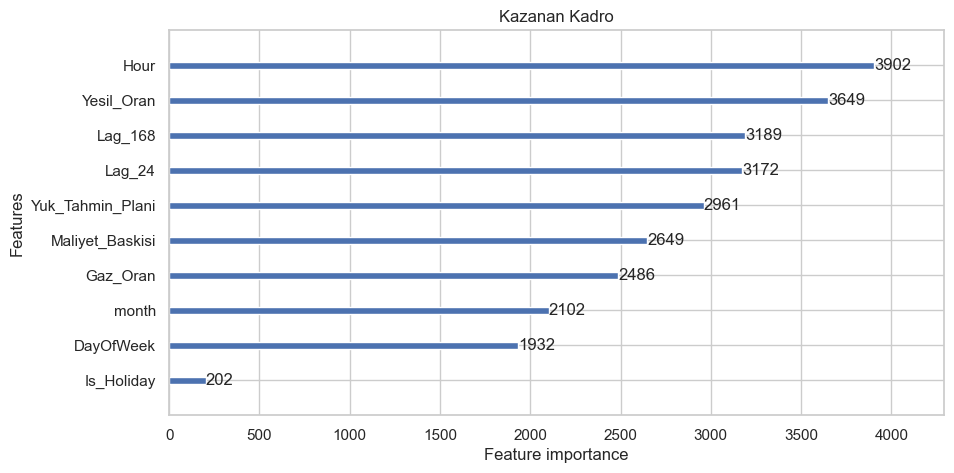

In [47]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd


# ÖZELLİKLER (Senin en iyi sonuç aldığın set)
features_final = [
    'Hour', 'DayOfWeek', 'month', 'Is_Holiday',
    'Yuk_Tahmin_Plani',
    'Yesil_Oran', 
    'Gaz_Oran',       
    'Lag_24', 'Lag_168',
    'Maliyet_Baskisi' # Tek Fiyat Sinyali
]

# PARAMETRELER (Manuel "Sniper" Ayarı - Daha agresif öğrenme)
params_champion = {
    'objective': 'regression',
    'metric': 'mae',
    'n_estimators': 6000,       # Yeterince uzun koşsun
    'learning_rate': 0.015,     # Optuna'nın bulduğundan muhtemelen daha hızlı
    'num_leaves': 55,           # Biraz daha karmaşık ağaçlara izin verelim
    'max_depth': 12,            
    'min_child_samples': 20,    # Biraz daha hassas olsun (Gürültüye takılmasın)
    'subsample': 0.8,           
    'colsample_bytree': 0.8,    
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

# Modeli Kur
champion_model = lgb.LGBMRegressor(**params_champion)

# Eğit
champion_model.fit(
    X_train_opt[features_final], y_train_opt,
    eval_set=[(X_test_opt[features_final], y_test_opt)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)

# Sonuçları Gör
preds = champion_model.predict(X_test_opt[features_final])
mae = mean_absolute_error(y_test_opt, preds)
r2 = r2_score(y_test_opt, preds)

print("\n" + "="*40)
print(f"R2 Skoru : {r2:.4f}")
print(f"MAE      : {mae:.2f} TL")
print("="*40)

# Feature Importance'a son kez bakalım
lgb.plot_importance(champion_model, max_num_features=15, title='Kazanan Kadro', figsize=(10, 5))
plt.show()

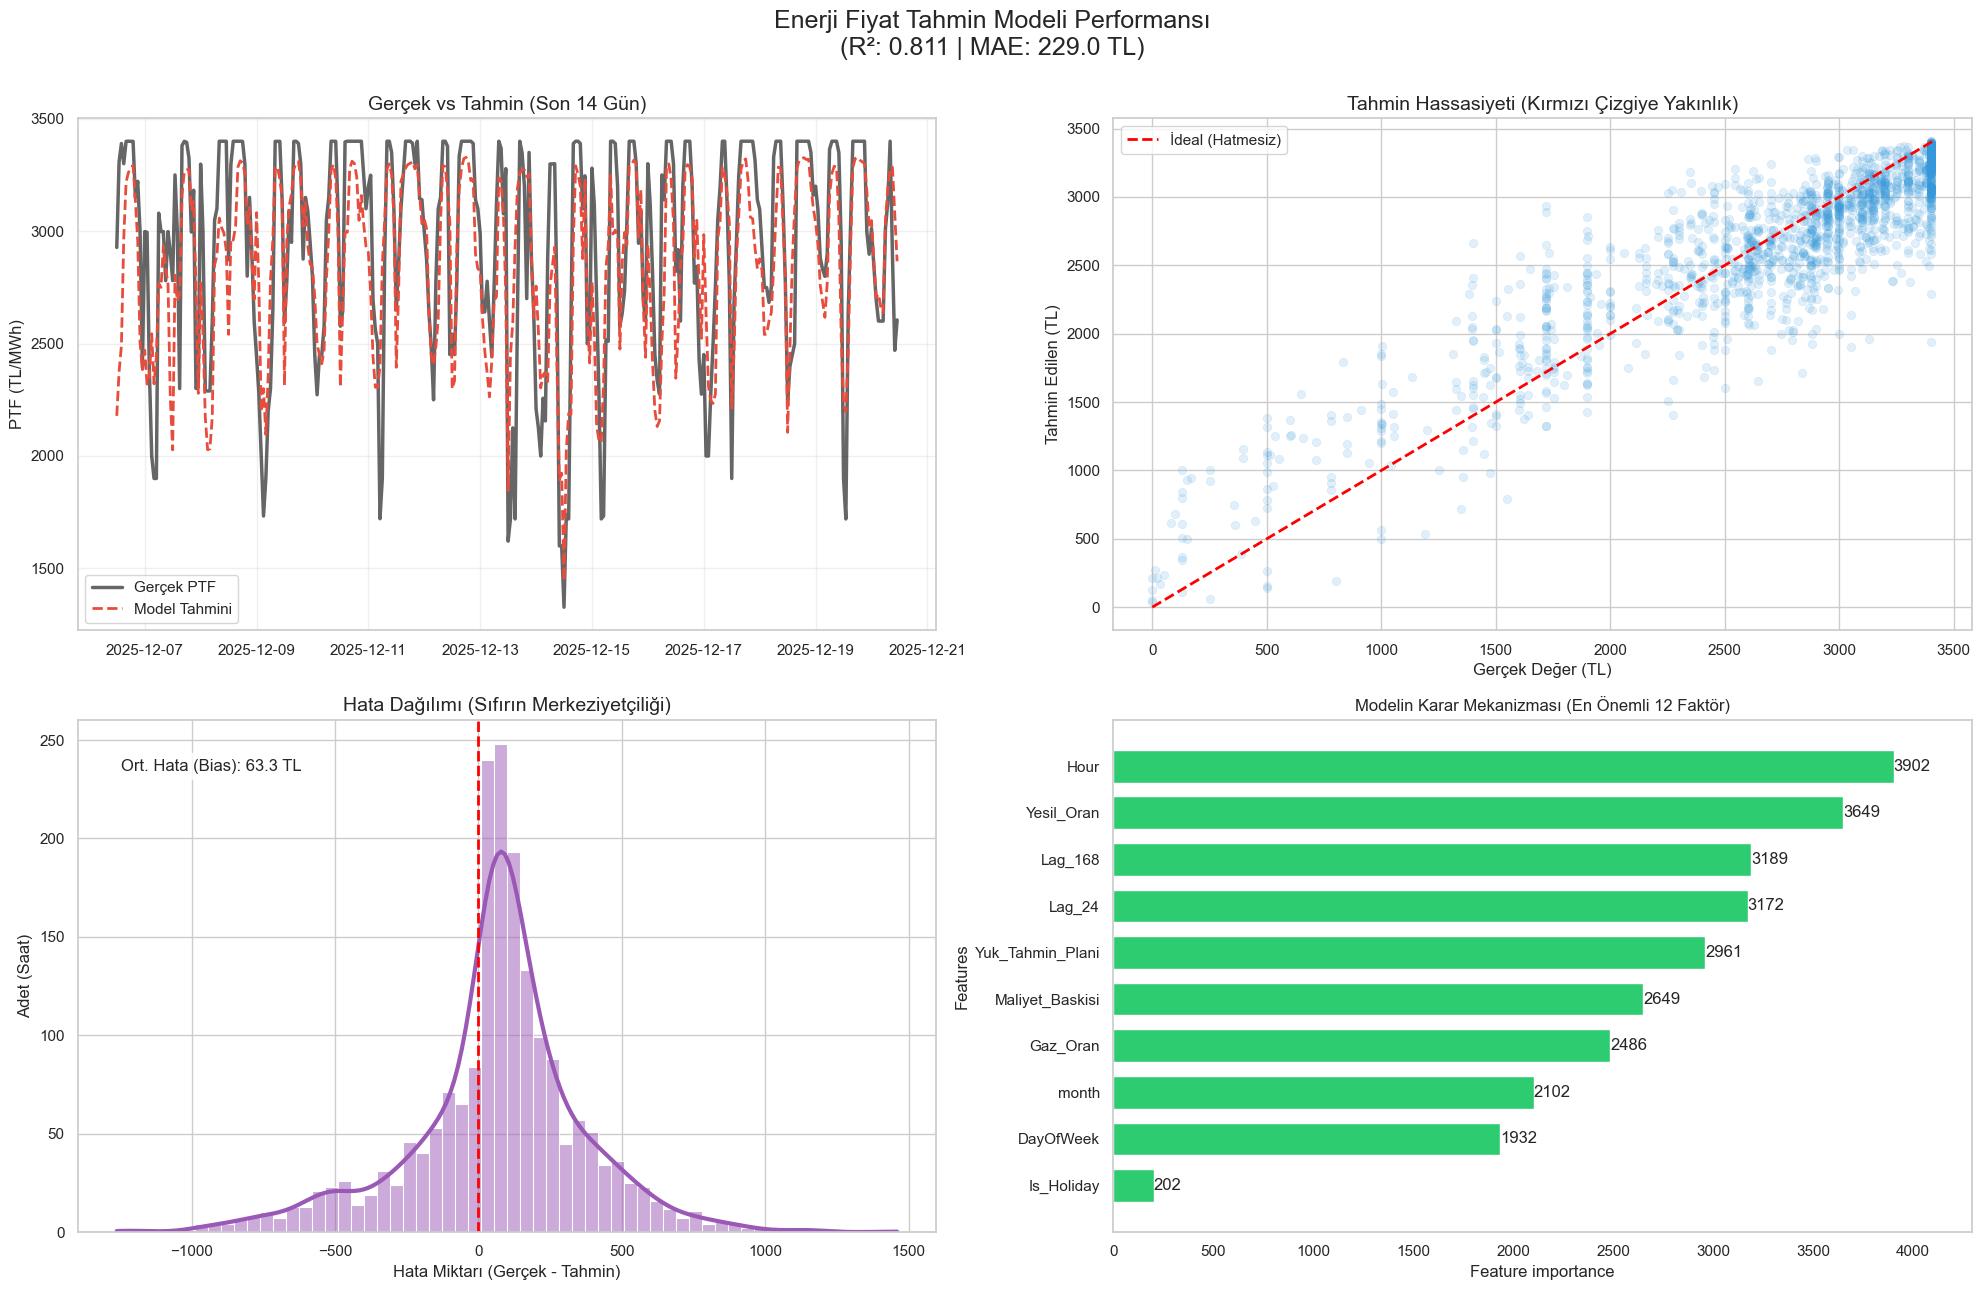

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Görsellik ayarları
sns.set(style="whitegrid", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'

# 1. TAHMİNLERİ AL (Eğer model hafızadaysa)
preds_final = champion_model.predict(X_test_opt[features_final])

# Skorları bir kenara yazalım
r2_text = f"R²: {r2_score(y_test_opt, preds_final):.3f}"
mae_text = f"MAE: {mean_absolute_error(y_test_opt, preds_final):.1f} TL"

# 2. TUVALİ HAZIRLA (2x2 Izgara)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle(f"Enerji Fiyat Tahmin Modeli Performansı\n({r2_text} | {mae_text})", fontsize=18, y=0.95)

# --- GRAFİK 1 (SOL ÜST): ZAMAN ÇİZELGESİ (ZOOM) ---
# Model ani fiyat sıçramalarını (Peak) yakalayabiliyor mu?
# Son 14 günü (336 saat) gösterelim.
results_df = pd.DataFrame({'Gerçek': y_test_opt, 'Tahmin': preds_final}, index=X_test_opt.index)
zoom_data = results_df.tail(24 * 14) # Son 2 hafta

axes[0, 0].plot(zoom_data.index, zoom_data['Gerçek'], label='Gerçek PTF', color='black', linewidth=2.5, alpha=0.6)
axes[0, 0].plot(zoom_data.index, zoom_data['Tahmin'], label='Model Tahmini', color='#e74c3c', linestyle='--', linewidth=2)
axes[0, 0].set_title('Gerçek vs Tahmin (Son 14 Gün)', fontsize=14)
axes[0, 0].set_ylabel('PTF (TL/MWh)')
axes[0, 0].legend(frameon=True)
axes[0, 0].grid(True, alpha=0.3)

# --- GRAFİK 2 (SAĞ ÜST): TAHMİN DOĞRULUĞU (SCATTER) ---
# Modelin "Hassasiyeti" ne kadar? İnce bir çizgi mi, dağınık bir bulut mu?
sns.scatterplot(x=y_test_opt, y=preds_final, alpha=0.15, color='#3498db', edgecolor=None, ax=axes[0, 1])
# İdeal (1:1) çizgisi
line_coords = [0, max(y_test_opt.max(), preds_final.max())]
axes[0, 1].plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='İdeal (Hatmesiz)')
axes[0, 1].set_title('Tahmin Hassasiyeti (Kırmızı Çizgiye Yakınlık)', fontsize=14)
axes[0, 1].set_xlabel('Gerçek Değer (TL)')
axes[0, 1].set_ylabel('Tahmin Edilen (TL)')
axes[0, 1].legend()

# --- GRAFİK 3 (SOL ALT): HATA DAĞILIMI (BIAS) ---
# Modelin sistematik bir hatası var mı? (Sürekli eksik/fazla söyleme)
residuals = y_test_opt - preds_final
sns.histplot(residuals, bins=60, kde=True, color='#9b59b6', line_kws={'linewidth': 3}, ax=axes[1, 0])
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2) # Sıfır noktası
axes[1, 0].set_title(f'Hata Dağılımı (Sıfırın Merkeziyetçiliği)', fontsize=14)
axes[1, 0].set_xlabel('Hata Miktarı (Gerçek - Tahmin)')
axes[1, 0].set_ylabel('Adet (Saat)')
# Ortalama hatayı yazalım
bias_text = f"Ort. Hata (Bias): {residuals.mean():.1f} TL"
axes[1, 0].text(0.05, 0.9, bias_text, transform=axes[1, 0].transAxes, bbox=dict(facecolor='white', alpha=0.8))

# --- GRAFİK 4 (SAĞ ALT): FEATURE IMPORTANCE (YILDIZ KİM?) ---
# Hangi veri modeli sırtlıyor?
lgb.plot_importance(champion_model, max_num_features=12, height=0.7, ax=axes[1, 1], 
                    title='Modelin Karar Mekanizması (En Önemli 12 Faktör)', color='#2ecc71')
axes[1, 1].grid(False) # Daha temiz görünsün

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Başlık için yer aç
plt.show()

In [54]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# 1. TAHMİNLERİ OLUŞTUR
# (Modelin test seti üzerinde ne dediğini öğrenelim)
preds = champion_model.predict(X_test_opt[features_final])

# 2. METRİKLERİ HESAPLA
# R2: Varyansı açıklama gücü (1'e ne kadar yakınsa o kadar iyi)
r2 = r2_score(y_test_opt, preds)

# MAE: Ortalama kaç TL sapıyoruz?
mae = mean_absolute_error(y_test_opt, preds)

# WMAPE: Hata payımız yüzde kaç? (Enerji sektörünün standardıdır)
wmape = (np.sum(np.abs(y_test_opt - preds)) / np.sum(y_test_opt)) * 100

# BIAS: Model sürekli eksik mi söylüyor, fazla mı?
# Pozitif çıkarsa: Model fiyatı genelde DÜŞÜK tahmin ediyor demektir.
bias = np.mean(y_test_opt - preds)

# 3. SONUÇLARI YAZDIR
print("="*40)
print(f"MODEL PERFORMANS METRİKLERİ")
print("="*40)
print(f" R2 Skoru   : {r2:.4f}")
print(f" MAE        : {mae:.2f} TL")
print(f" WMAPE      : %{wmape:.2f}")
print(f" Bias       : {bias:.2f} TL")
print("="*40)


MODEL PERFORMANS METRİKLERİ
 R2 Skoru   : 0.8111
 MAE        : 228.98 TL
 WMAPE      : %8.15
 Bias       : 63.32 TL


modelde hava durumu ve haftasonu bilgisi eksik. Dipleri ve pikleri yakalamak için eklemeleyiz. 07-model-4 dosyasında..

In [ ]:
veri.to_pickle('../data/processed/06_model-3.pkl') 